# PyG Implementation of MeshGraphNets

In this Colab, we provide all of the code discussed in our Medium blog post, Learning Mesh-Based Flow Simulations on Graph Networks, by Isaac Ju, Robert Lupoiu, and Rayan Kanfar, as part of the Stanford CS224W course project.

NOTE: TO ACCESS THE DATASETS AND FILES ACCOMPANYING THIS COLAB, PLEASE FOLLOW THE FOLLOWING LINK: https://drive.google.com/drive/folders/12QaYm2Y6H4UJ0dit9us4cfN7HelpLXvD?usp=sharing

This code is based on the paper by T. Pfaff et al., Learning Mesh-Based Simulation with Graph Networks (2021) ICLR. DeepMind provides their codebase for this project, but it is written in TensorFlow. Here, we write the code from the ground up based on the description given in the original paper in PyG, a framework for building graph neural networks (GNNs) in PyTorch, which is much more suitable for quickly iterating and experimenting with GNNs. The original codebase provided by DeepMind is available here: https://github.com/deepmind/deepmind-research/tree/master/meshgraphnets.

In this notebook, the task is to build, train, and evaluate the performance of MeshGraphNets built using PyG. This is done in an instructive manner. At a high level, in this notebook we first either pre-process the CylinderFlow dataset into a PyG-workable format or import an already pre-processed PyG dataset, we build MeshGraphNets using the PyG framework, and we then use a training and testing pipeline that we build to test the performance of MeshGraphNets on several datasets. Recall from the Medium article that the goal is to learn how to predict the acceleration of a fluid on a mesh domain at the nodes of a GNN. The results are then visualized at the end.

**Note:** Make sure to sequentially run the cells in each section so that intermediate variables and dependency imports carry over. The single exception is the data pre-processing code. This can be skipped and the alread processed data we provided can be used instead.

We hope that you will find this code useful in your learning, research, or work. Thank you for taking the time to look through!

# Acessing Pre-Processed Datasets

In order to access the preprocessed datasets, we will need to implement a little Google Colab workaround in order to access them without downloading them to your own Drive. We will mount the directories used in this Colab to this instance. If you're not sure how to do that, please follow these steps:

1.   Go to the root directory in which this file is located (named MeshGraphNets_PyG)
2.   Right-click on the ./datasets folder and select "Add shortcut to Drive"
3.   Create a shortcut of ./datasets ./animations ./best_models in "My Drive"
4.   Run the cell below and follow the prompts in the pop-up windows. Allow Google Colab to access your Drive so that you it can view the shortcut that you just created.

After completing the steps listed above, you will have access to all of the datasets in the ./datasets folder!

In [ ]:
import random
from pathlib import Path
import numpy as np
import torch
import icemesh.model as m
import icemesh.postprocessing as post
import icemesh.preprocessing as prep
import icemesh.train_test as tt

print("PyTorch has version {}".format(torch.__version__))

PyTorch has version 2.7.1


# Preparing and Loading the Dataset

Here we show how we processed the dataset to prepare it to work with PyG. We also provided some pre-processed datasets that you can use directly. We first converted these to h5 format to make the data easier to handle with PyTorch and NumPy. This is then processed below.

First, we need to define the root directory and the directories of the datasets, where to save the checkpoint, and where to store animations. The defaults given below will work if you followed the instructions in the first cell above.

In [2]:
dataset_dir = Path.cwd() / "datasets"
checkpoint_dir = Path.cwd() / "best_models"
animation_dir = Path.cwd() / "animations"
postprocess_dir = Path.cwd() / "2d_loss_plots"

dataset_dir

PosixPath('/Users/clairedonnelly/Documents/IceGraph/icemesh/datasets')

**Data Pre-Processing Code**

We begin by first importing all of the needed dependencies for data processing

In [3]:
# Define the data folder and data file name
datafile = Path(dataset_dir, 'valid.h5')

# Define the time difference between the graphs
dt=0.01   # A constant: do not change!

# Define the number of trajectories and time steps within each to process.
number_trajectories = 10
number_ts = 60

Each trajectory has 600 timesteps. Each trajectory (mesh) has a unique connectivity, which is described by cells. Cells has a shape of (**timestep, cell_num, 3**). Each cell is consisted of three vertices whose index is given by querying cell_to_vertex map. Mesh_pos gives a unique set of vertex coordinates.

Below we loop through the h5 file that was converted from tfrecord and collect all of the information and store it in a torch_geometric Data instance, as described in the Medium post. Each section of code is described with in-line comments.

In [4]:
file_path = Path(dataset_dir, 'test_processed_set.pt')
dataset = prep.convert_to_torch(datafile, file_path, number_trajectories, number_ts, dt)

len(dataset)/5

preprocessed dataset found at /Users/clairedonnelly/Documents/IceGraph/icemesh/datasets/test_processed_set.pt


120.0

**Normalization**

Normalization is necessary for the features and output parameters to zero mean and unit variance in order to stabilize training. The method defined below, get_stats(), is run before training. It accepts the processed data_list, calculates the mean and standard deviation for the node features, edge features, and node outputs, and normalizes these using the calculated statistics.

# Building the Model

# MeshGraphNet Class: Encoding, Processing, and Decoding

MeshGraphNets has three components: encoder, processor and decoder

### Encoder
The encoder is a preprocessing step to the GNN blocks (processor). We have two seperate encoders: edge and node encoders. Specifically, encoders are tasked with generating the node and edge embeddings from the initial features of the graph. Remember, the initial node embeddings are the concatenated velocity at a specific time step with the one-hot node type vector. The initial edge embeddings are the concatenation of relative position vector and its norm. The encoding function is an MLP with ReLU activation normalized by LayerNorm. Mathematically, the node encoding is simply:

$$
\mathbf{z}_{i} = \textrm{MLP} ( \mathbf{h}_{i}) \;      \forall i \in V
$$

the edge encoding is thus:

$$
\mathbf{z}_{ij} = \textrm{MLP} ( \mathbf{h}_{ij}) \;      \forall edges \in E
$$

### Processor

The processor is the GNN message passing, aggregation, and update part of the architecture. It takes the graph with the new features generated by the encoder through the GNN pipeline: message, aggregation, and updates for the number of layers chosen.
The processing layers of the MeshGraphNets is handled by a separate class, ProcessorLayer, which inherits from the PyG MessagePassing base class. The message is a learned transformation of MLP with skip connection on the self edge embedding concatenated with the embeddings of the conneccting nodes. The aggregation is done in two steps: 1) sum over the connected edges of each node, 2) another MLP transformation of the edge sum concatenated with the self node.

### Decoder

The decoder is a postprocessing step. It takes the node updates from the processor and maps it into a change in velocity, or acceleration, using another seperatly learned MLP.


Finally, let's start by coding MeshGraphNet.

*Note: In the original study, the MLPs used in encoding, processing, and decoding have two hidden layers. For this code to run in Colab in a reasonable amount of time, the implementation below uses only one hidden layer.*

ProcessorLayer inherits from the PyG MessagePassing base class and handles processor/GNN part of the architecture. 👇

# ProcessorLayer Class: Edge Message Passing, Aggregation, and Updating

Now let's implement the processor, which overrides "[MessagePassing](https://pytorch-geometric.readthedocs.io/en/latest/notes/create_gnn.html)" base class. Following the prototype of the base class, we need to implement three main methods, namely message passing, aggregation, and updating. Also, two types of MLP layers, namely node MLP and edge MLP, are defined and used during the construction of processor, whose details will be given in the cell bellow.

Essentailly, our processor class serves as the GNN layers composed of message passing, aggregation, and updating, updating information at each layer of the computational graph for each node. The message passing process can be described as:

1.   **Message passing**

Initiated by the propagate function, the message function most generally calculates messages, m, for edge u at layer l with function MSG given previous embeddings h_u:
$$m_u^{(l)}=MSG^{(l)}(h_u^{(l-1)})$$

Note that for MeshGraphNets, messages are calculated for edges and passed to nodes. This function thus takes edge embeddings and the adjacent node embeddings and concatenates them. These concatenated previous embeddings constitute h_u above. These are then put through an MLP (our MSG function) to give the final messages, m_u, which are passed to the aggregate function.

2.   **Aggregation**

Aggregation takes the updated edge embeddings and aggregates then over the connectivity matrix indexing using sum reduction. Most generally, we have:

$$h_v^{(l)}=AGG^{(l)}(\{m_u^{(l)},u\in N(v)\})$$

For MeshGraphNets, aggregation (AGG) for node v is sum over the neighbor nodes. However, there is also an additional aggregation step: aggregating with the self embedding. This is done outside of the aggregation function, in the forward function after the return of propagate:

$$h_v^{(l)}=\{h_v^{(l-1)},AGG^{(l)}(\{m_u^{(l)},u\in N(v)\})\}$$

3.   **Updating**

The nodes embeddings are finally updated by passing $h_v^{(l)}$ through the node MLP with a skip connection. This is most generally written as:

$$h_v^{(l)}=Processor(h_v^{(l)})$$

Where for us the Processor is an MLP.


## Edge and Node MLP

We define two kind of MLP layers for edge and node, respectively. Both MLPs have the same hidden dimension (out_channels) and layer structures: two linear layers, a non-linear ReLu layer and a norm layer. But, their input dimensions are different: edge MLP takes two connecting node embeddings and the edge embedding of itself, whereas node MLP takes aggregated messages from its surrounding edges and the self node embedding.

# Building the Optimizer

Here we include a function that lets us play with the optimizer and learning rate scheduler. This was provided as part of assignments in Stanford's CS 224W class on [Machine Learning with Graphs](http://web.stanford.edu/class/cs224w/).

In this Colab we use the Adam Optimizer, like in the original MeshGraphNets paper, but you are free to try other ones to experiment with the performance of the training of the network!

# Training and Testing

Here we define our training and testing + validation pipelines. Note that these standard given that we defined our MeshGraphNets class to inherit from torch.nn.Module, like a standard PyTorch neural network!

train() iterates through the data for the specified number of epochs, calling the MeshGraphNets class forward functions to get the final decoded node values, and calling the loss function to calculate loss given ground truth data. This is then backpropagated through the network using PyTorch built-in modules to optimize the learned parameters of the MLPs of MeshGraphNets.

For every tenth epoch (to save computation time), the test loss is calculated on the test dataset, and the validation loss is calculated by calculating the velocities from the predicted accelerations of the network. These are added to the returned performance lists. The code below is commented by line for further explanation.

# Let's prepare the model for training!

Specify parameters for model training

In [5]:
class objectview(object):
    def __init__(self, d):
        self.__dict__ = d

for args in [
        {'model_type': 'meshgraphnet',
         'num_layers': 10,
         'batch_size': 2,
         'hidden_dim': 10,
         'epochs': 1000,
         'opt': 'adam',
         'opt_scheduler': 'none',
         'opt_restart': 0,
         'weight_decay': 5e-4,
         'lr': 0.001,
         'train_size': 10,
         'test_size': 2,
         'device':'cpu',
         'shuffle': True,
         'save_velo_val': True,
         'save_best_model': True},
    ]:
        args = objectview(args)

#To ensure reproducibility the best we can, here we control the sources of
#randomness by seeding the various random number generators used in this Colab
#For more information, see: https://pytorch.org/docs/stable/notes/randomness.html
torch.manual_seed(5)  #Torch
random.seed(5)        #Python
np.random.seed(5)     #NumPy

Load the dataset

In [6]:
dataset = torch.load(file_path, weights_only=False)[:(args.train_size+args.test_size)]

Shuffle the dataset and get the statistics of the dataset

In [7]:
if(args.shuffle):
  random.shuffle(dataset)

stats_list = prep.get_stats(dataset)

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

args.device = device
print(device)

mps


In [8]:
dataset[0].x

tensor([[ 0.0646,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0324,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0669, -0.0043,  1.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  1.0000,  0.0000,  0.0000],
        [ 0.0715, -0.0081,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  1.0000,  0.0000,  0.0000]])

# Training

Start the training!

NOTE: This cell takes about 45 minutes to run on Colab Pro

In [9]:
test_losses, losses, velo_val_losses, best_model, best_test_loss, test_loader = tt.train(dataset, device, stats_list, args, checkpoint_dir)

print("Min test set loss: {0}".format(min(test_losses)))
print("Minimum loss: {0}".format(min(losses)))
if (args.save_velo_val):
    print("Minimum velocity validation loss: {0}".format(min(velo_val_losses)))

/Users/clairedonnelly/Documents/IceGraph/icemesh/.venv/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


5
1


Training:   0%|          | 0/1000 [00:00<?, ?Epochs/s]/Users/clairedonnelly/Documents/IceGraph/icemesh/src/icemesh/train_test.py:125: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)
Training:   0%|          | 1/1000 [00:01<21:04,  1.27s/Epochs]

train loss 1.92 test loss 1.1 velo loss 0.00545


Training:  10%|█         | 101/1000 [01:01<08:41,  1.72Epochs/s]

...

train loss 0.2 test loss 0.17 velo loss 0.00106


Training:  90%|█████████ | 901/1000 [08:13<00:55,  1.80Epochs/s]

train loss 0.24 test loss 0.15 velo loss 0.00103


Training: 100%|██████████| 1000/1000 [09:07<00:00,  1.83Epochs/s]

Min test set loss: 0.12199216336011887
Minimum loss: 0.15726435631513597
Minimum velocity validation loss: 0.0009269890142604709


Let's visualize the results!

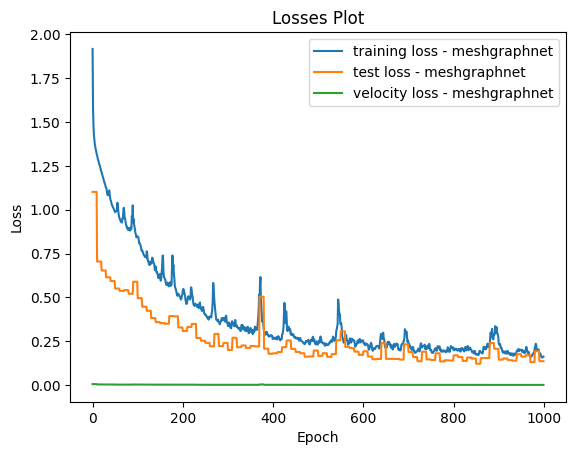

In [ ]:
post.save_plots(args, losses, test_losses, velo_val_losses, postprocess_dir)

What happens if we train on more data? Let's test it out...

Define new parameters with a larger training set:

In [12]:
for args in [
        {'model_type': 'meshgraphnet',
         'num_layers': 10,
         'batch_size': 16,
         'hidden_dim': 10,
         'epochs': 5000,
         'opt': 'adam',
         'opt_scheduler': 'none',
         'opt_restart': 0,
         'weight_decay': 5e-4,
         'lr': 0.001,
         'train_size': 45,
         'test_size': 10,
         'shuffle': True,
         'save_velo_val': True,
         'save_best_model': True,
        }
]:
        args = objectview(args)

#To ensure reproducibility the best we can, here we control the sources of
#randomness by seeding the various random number generators used in this Colab
#For more information, see: https://pytorch.org/docs/stable/notes/randomness.html
torch.manual_seed(5)  #Torch
random.seed(5)        #Python
np.random.seed(5)     #NumPy

dataset = torch.load(file_path, weights_only=False)[:(args.train_size+args.test_size)]

if(args.shuffle):
            random.shuffle(dataset)

stats_list = prep.get_stats(dataset)

Note: This cell takes about 1.5 hours to run on Colab Pro.

In [13]:
test_losses, losses, velo_val_losses, best_model, best_test_loss, test_loader = tt.train(dataset, device, stats_list, args, checkpoint_dir)

print("Min test set loss: {0}".format(min(test_losses)))
print("Minimum loss: {0}".format(min(losses)))
if (args.save_velo_val):
    print("Minimum velocity validation loss: {0}".format(min(velo_val_losses)))

/Users/clairedonnelly/Documents/IceGraph/icemesh/.venv/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


3
1


Training:   0%|          | 0/5000 [00:00<?, ?Epochs/s]/Users/clairedonnelly/Documents/IceGraph/icemesh/src/icemesh/train_test.py:125: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)
Training:   0%|          | 1/5000 [00:01<1:47:09,  1.29s/Epochs]

train loss 2.0 test loss 1.62 velo loss 0.00562


Training:   2%|▏         | 101/5000 [00:59<48:52,  1.67Epochs/s]

...

train loss 0.16 test loss 0.42 velo loss 0.00137


Training:  98%|█████████▊| 4901/5000 [47:03<00:59,  1.68Epochs/s]

train loss 0.15 test loss 0.4 velo loss 0.00145


Training: 100%|██████████| 5000/5000 [48:00<00:00,  1.74Epochs/s]

Min test set loss: 0.3469688296318054
Minimum loss: 0.1312351773182551
Minimum velocity validation loss: 0.0012450636131688952


Now, let's visualize these latest results

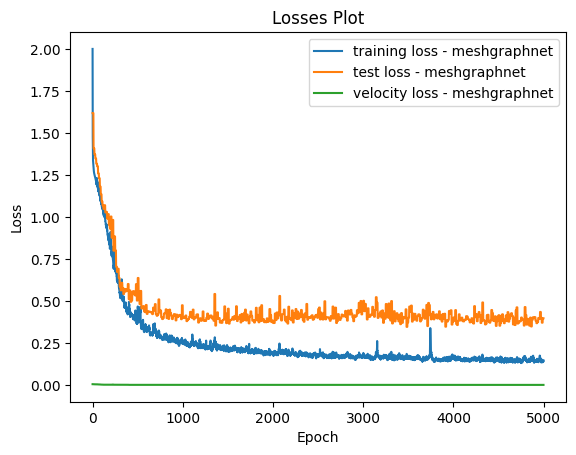

In [ ]:
post.save_plots(args, losses, test_losses, velo_val_losses, postprocess_dir)

Much less overfitting with more data and lower training loss! (Notice the y axis scale, corresponding to loss 👀) Beautiful 😍

Can we generalize to different trajectories (i.e., different graph structures)? Below we train on 9 trajectories, each containing 5 time steps.

In [15]:
file_path = Path(dataset_dir, 'test_processed_set.pt')

for args in [
        {'model_type': 'meshgraphnet',
         'num_layers': 10,
         'batch_size': 16,
         'hidden_dim': 10,
         'epochs': 5000,
         'opt': 'adam',
         'opt_scheduler': 'none',
         'opt_restart': 0,
         'weight_decay': 5e-4,
         'lr': 0.001,
         'train_size': 45, #Train on 9 trajectories x 5 time steps
         'test_size': 10,  #Test on 10 time steps of two more trajectories
         'shuffle': False,       #Turn off shuffling so that data can be tested on completely unseen trajectories
         'save_velo_val': True,
         'save_best_model': True,
         },
    ]:
        args = objectview(args)

#To ensure reproducibility the best we can, here we control the sources of
#randomness by seeding the various random number generators used in this Colab
#For more information, see: https://pytorch.org/docs/stable/notes/randomness.html
torch.manual_seed(5)  #Torch
random.seed(5)        #Python
np.random.seed(5)     #NumPy

dataset = torch.load(file_path, weights_only=False)[:(args.train_size+args.test_size)]

if(args.shuffle):
            random.shuffle(dataset)

stats_list = prep.get_stats(dataset)

Note: this cell takes about 45 minutes to run on Colab Pro.

In [17]:
test_losses, losses, velo_val_losses, best_model, best_test_loss, test_loader = tt.train(dataset, device, stats_list, args, checkpoint_dir)

print("Min test set loss: {0}".format(min(test_losses)))
print("Minimum loss: {0}".format(min(losses)))
if (args.save_velo_val):
    print("Minimum velocity validation loss: {0}".format(min(velo_val_losses)))

/Users/clairedonnelly/Documents/IceGraph/icemesh/.venv/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


3
1


Training:   0%|          | 0/5000 [00:00<?, ?Epochs/s]/Users/clairedonnelly/Documents/IceGraph/icemesh/src/icemesh/train_test.py:125: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)
Training:   0%|          | 1/5000 [00:01<1:31:57,  1.10s/Epochs]

train loss 1.98 test loss 0.83 velo loss 0.00267


Training:   2%|▏         | 101/5000 [01:00<49:55,  1.64Epochs/s]

...

train loss 0.19 test loss 0.15 velo loss 0.00048


Training:  98%|█████████▊| 4901/5000 [46:51<00:59,  1.67Epochs/s]

train loss 0.15 test loss 0.13 velo loss 0.00035


Training: 100%|██████████| 5000/5000 [47:47<00:00,  1.74Epochs/s]

Min test set loss: 0.12730029225349426
Minimum loss: 0.12907477716604868
Minimum velocity validation loss: 0.00034964035148732364


Visualization:

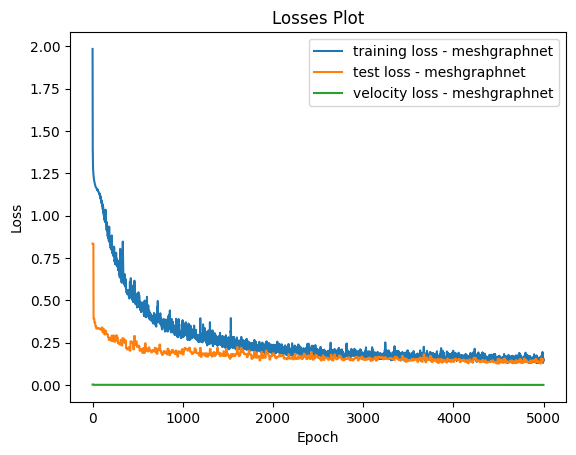

In [ ]:
post.save_plots(args, losses, test_losses, velo_val_losses, postprocess_dir)

We notice that the loss curves are very similar to those of the single trajectory case! We generalize very well to different trajectories!

# Let's load model and animate flow field

With the methods below, we visualize the results from a model trained in this colab or a pre-trained model that we import from elsewhere.

First, let's implement functions for visualizing flow fields. The tricky part here is to plot all predicted flow velocity (x-velocity in this case) on a mesh. The built-in function of [tri](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.triplot.html) came into rescue. Triplot allows us to draw a unstructured triangular grid as lines, which suits our purpose perfectly.🌐

If you have been waiting through the two trainings, you can simply **skip the following cell** and just run through the visualization cell right after. ⏭

Or, if any of you would like to have a taste what the prediction would be like, we got you coverd. We have provided two trained models saved from above. You need to **load the models** first so that the animation functions will work properly.👇

Here we only review the **good one** (more data)

In [20]:
# load model.
args.device = torch.device('cpu') # animation function cannot work with data on GPU
num_node_features = dataset[0].x.shape[1]
num_edge_features = dataset[0].edge_attr.shape[1]
num_classes = 2 # the dynamic variables have the shape of 2 (velocity)
PATH = Path(checkpoint_dir, 'model_nl10_bs16_hd10_ep5000_wd0.0005_lr0.001_shuff_True_tr45_te10.pt')
model = m.MeshGraphNet(num_node_features, num_edge_features, args.hidden_dim, num_classes,
                            args).to(args.device)

model.load_state_dict(torch.load(PATH, map_location=args.device))

<All keys matched successfully>

Now let's us make animations 🎥 This process might take a while depending on how many frames of velocity fields are plotted.

Generating velocity fields...
55


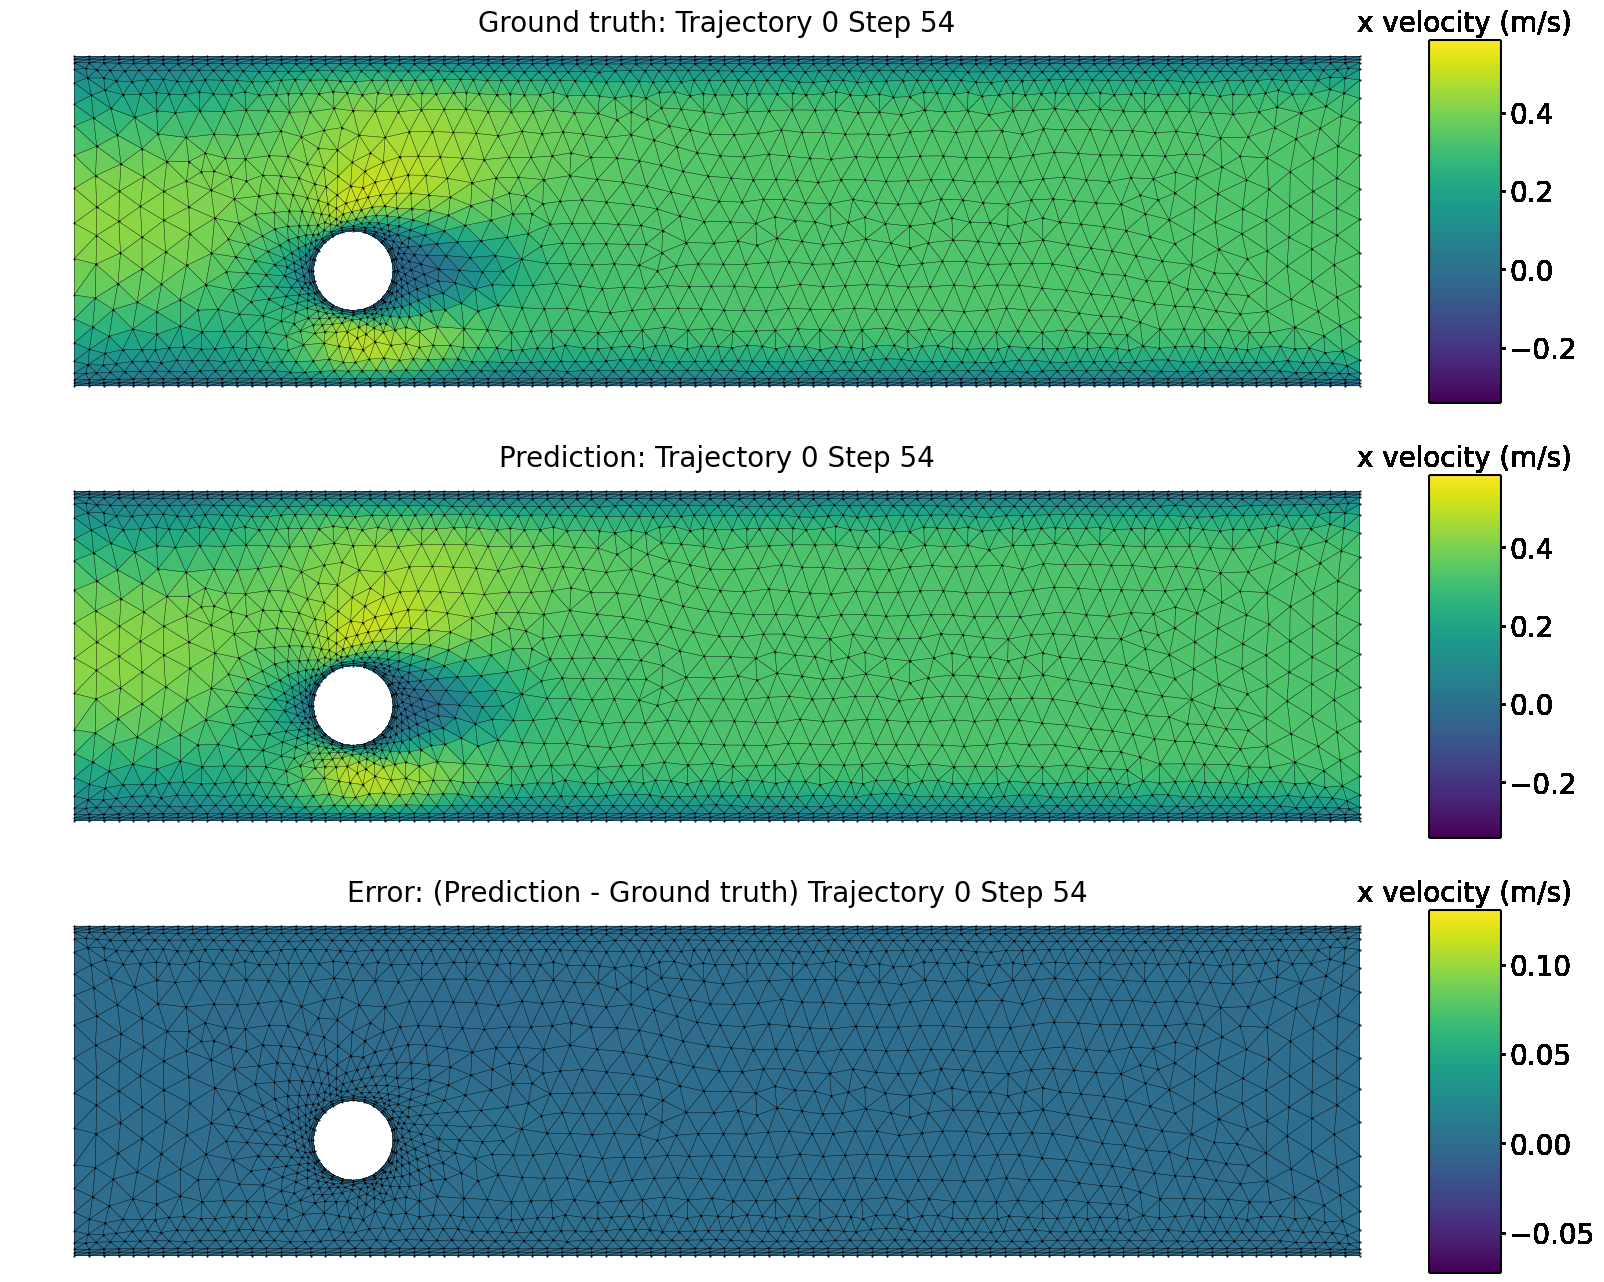

In [ ]:
# visualize predicted velocities
animation_name = 'x_velocity'

eval_data_loader = post.visualize(dataset, model, animation_dir, args, animation_name, stats_list,
           delta_t = 0.01, skip = 1)

So now you have generated a gif named *x_velocity.gif* at the *animations* folder.  

You can download this gif file by clicking download on the *Folder* icon on the left side pannel. Then you can check offline.